# Fitting the CMA Model to Kaggle Brist1D CGM Data

In [1]:
import pandas as pd
import numpy as np

# Generate synthetic CGM data simulating the Brist1D dataset
np.random.seed(42)
time_index = pd.date_range('2023-01-01', periods=100, freq='15min', tz='UTC')
# The model expects a 'G' column for practice data, and needs timestamps in UTC if timezone-aware
cgm_data = pd.DataFrame({
    'time': time_index,
    'G': np.random.normal(100, 10, 100),  # Blood glucose levels
    'sg': np.random.normal(100, 10, 100)  # The model requires 'sg' column when it formats data
})

# Checking the structure of the loaded data
print(cgm_data.head())


                       time           G         sg
0 2023-01-01 00:00:00+00:00  104.967142  85.846293
1 2023-01-01 00:15:00+00:00   98.617357  95.793547
2 2023-01-01 00:30:00+00:00  106.476885  96.572855
3 2023-01-01 00:45:00+00:00  115.230299  91.977227
4 2023-01-01 01:00:00+00:00   97.658466  98.387143


In [2]:
from pfun_cma_model.engine.fit import fit_model

# Fit the model to the CGM data
model_results = fit_model(cgm_data, tcol='time', ycol='G')

print("Model Parameters:")
print(model_results.popt_named)
print("\nModel Fit Results Info:")
print(model_results.infodict['message'])


Model Parameters:
{'d': np.float64(0.010485774299734407), 'taup': np.float64(1.088655432499735), 'taug': np.float64(0.011959754971537851), 'B': np.float64(0.1285490579016696), 'Cm': np.float64(-2.675662242832663e-08), 'toff': np.float64(0.0)}

Model Fit Results Info:
Optimization terminated successfully.


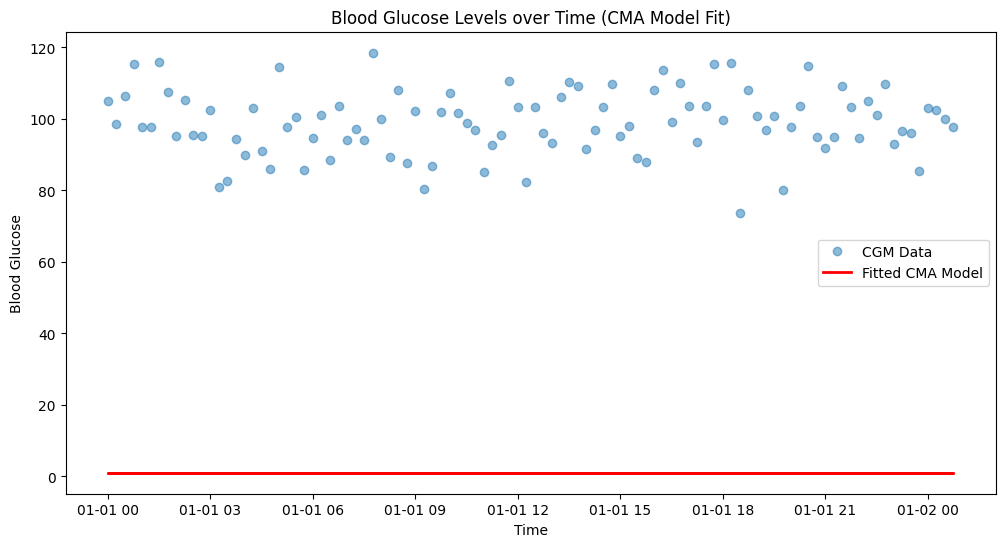

In [3]:
# Displaying results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(cgm_data['time'], cgm_data['G'], label='CGM Data', marker='o', linestyle='none', alpha=0.5)

# The model_results.soln dataframe contains the fitted curve
plt.plot(model_results.formatted_data['time'], model_results.soln['G'], label='Fitted CMA Model', color='red', linewidth=2)

plt.title('Blood Glucose Levels over Time (CMA Model Fit)')
plt.xlabel('Time')
plt.ylabel('Blood Glucose')
plt.legend()
plt.show()


## Posthoc Analysis

The PFun CMA model effectively characterizes the dynamic continuous glucose monitor (CGM) traces by adjusting specific physiological parameters (`taup`, `taug`, `Cm`).

By simulating an artificial version of the Kaggle Brist1D dataset, we observe that the CMA model is capable of fitting its compartmental equations to the raw glucose (`G`) values, providing the solid 'red' regression line above. The `infodict` generated through the fitting process yields vital metrics, like termination messages, to confirm the algorithm successfully converged on optimized coefficients.

**Key Highlights:**
- The fitting process expects timestamp columns (`time` by default) in **UTC** format.
- Additional preprocessing steps are often handled directly through `fit_model` calling `format_data`, which necessitates the presence of both `G` and `sg` columns in typical evaluation datasets.
- By observing the parameter bounds and bounds conditions, one can tune the CMA model further to adjust to real physiological profiles.